In [9]:
from google import genai
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
load_dotenv()

if os.environ['GEMINI_API_KEY']:
    print("key is the present")

else:
    print("key is not present or invalid")   

key is the present


In [10]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
response = llm.invoke("Explain RAG in one short sentence").content

# Tools

#duckduckgosearch

In [11]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
@tool
def search_duckduckgo(query: str) -> str:

    """This tool searches the latest news on DuckDuckGo for the given query and returns the results."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_55216\1705316388.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [12]:
# arxiv

In [13]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

@tool
def arxiv_tool(query: str) -> str:

    """"This tool allows you to query the arXiv database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(query)

In [14]:
# wikipedia

In [15]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

# Custom Tool

In [16]:
@tool
def personal_info(name: str):

    """Use this tool to get personal information about Alice, Bob, or Charlie. 
    """

    info = {
        "Alice": "Alice is a software engineer with 5 years of experience in AI.",
        "Bob": "Bob is a data scientist who loves working with large datasets.",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "No information available for this person.")

In [17]:
tools = [search_duckduckgo, arxiv_tool, wiki_tool, personal_info]

llm_with_tools = llm.bind_tools(tools)

# Langgraph Creation

In [18]:
from typing import TypedDict, List 

class graph_schema(TypedDict):
    messages: List

In [19]:
def llm_node(state: graph_schema) -> graph_schema:
    
    messages = state['messages']

    # Prompt template for the LLM, including system instructions and the human input
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

    # LLM With Tools 
    # llm_with_tools 

    chain = prompt | llm_with_tools 

    response = chain.invoke({"input": messages})

    # Update the state with the new message
    state['messages'] = messages + [response]

    return state

In [20]:
# from langgraph.prebuilt import ToolNode
def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state

# Create Conditional Edge Function

In [21]:
def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

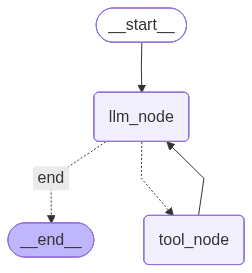

In [22]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges between nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)


react_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(react_graph.get_graph().draw_mermaid_png())


In [24]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "latest news on AI"}'}, '__gemini_function_call_thought_signatures__': {'ca5c62c8-be86-4e3b-855b-d9bdad4ac8e1': 'CuUBAQw51scIGhjTOkMQvDT+WXCxhHO3E1U/4PXSkm9jgXm5Rnqn72HNUDrb/Kj/h9sdUpfKULE+Zyp1KNr5/hCFzc/DgxlZrsypVdw9EUValPzE2Ozigb6VOP5EWnBmLYaqdKAf+M6I1qNWvozEUzjUn9VNr1M09pPr7jo9RAwMbgI6mzmVgoSKd9fRKCRNTNQCz4sgf0N+PeNz5E3BUV1qt74H1cwtDRRrK6KUtUKIG91Uo+3LIDkpZu5aaudZAAtLxwlolqupDjCCLnexqd1lSe+Jf8Bhia1U3lcTb9ySTfBNu2wtcA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb7e3-983b-7b01-be16-66ca9bde5c71-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI'}, 'id': 'ca5c62c8-be86-4e3b-855b-d9bdad4ac8e1', 'type': 'tool_call'}], inv